In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Step 1: Read and explore the data

In [2]:
data = pd.read_csv("auto-mpg.csv")

In [3]:
#Features in data set

#cylinders: contains the number of cylinders present in the car

#displacement: contains the Displacement of the car

#horsepower: contains the Horsepower of the car

#weight: contains the weight of the car

#acceleration: contains the Acceleration of the car

#model_year: contains the model year of the car

#origin: contains the origin country which car belong to

#car_name: contains the name of the car(Brand-Model-Variant)


#predict Miles per Gallon
#mpg: contains the fuel consumption value(in Miles per Gallon) for car

In [4]:
data.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


# Step 2: Data cleaning /missing value imputation

In [6]:
data['horsepower'] = data['horsepower'].str.replace('?','NaN').astype(float)
data['horsepower'].fillna(data['horsepower'].mean(),inplace=True)
data['horsepower'] = data['horsepower'].astype(int)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    int32  
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int32(1), int64(4), object(1)
memory usage: 26.6+ KB


In [8]:
data.describe(include='all').round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
mean,23.51,5.45,193.43,104.46,2970.42,15.57,76.01,1.57,NaN
std,7.82,1.70,104.27,38.20,846.84,2.76,3.70,0.80,NaN
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00,1.00,NaN
25%,17.50,4.00,104.25,76.00,2223.75,13.82,73.00,1.00,NaN
50%,23.00,4.00,148.50,95.00,2803.50,15.50,76.00,1.00,NaN
75%,29.00,8.00,262.00,125.00,3608.00,17.18,79.00,2.00,NaN


In [9]:
data.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

# Step 3: Univariate analysis

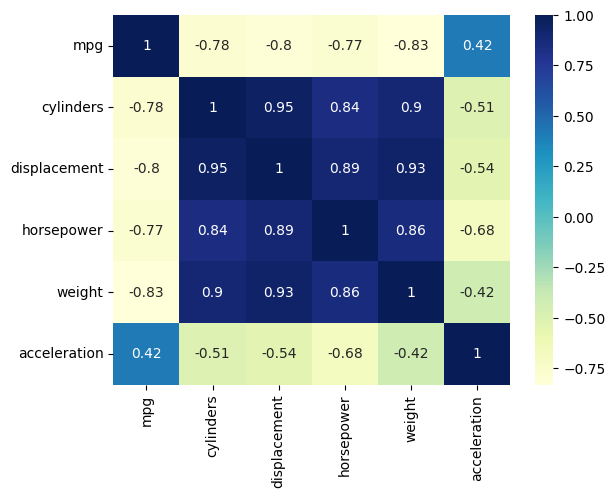

In [10]:
#Correlation of output with numerical variables
numerical_columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight','acceleration']
# plotting correlation heatmap
dataplot = sns.heatmap(data[numerical_columns].corr(), cmap="YlGnBu", annot=True)
  
# displaying heatmap
plt.show()

# Step 4: Create features and scale the data

In [11]:
data = pd.get_dummies(data,columns=['origin','model year'])  # create features
data.drop(columns=['car name'],axis=1,inplace=True) # drop unwanted data
data.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin_1,origin_2,origin_3,model year_70,...,model year_73,model year_74,model year_75,model year_76,model year_77,model year_78,model year_79,model year_80,model year_81,model year_82
0,18.0,8,307.0,130,3504,12.0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,15.0,8,350.0,165,3693,11.5,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,18.0,8,318.0,150,3436,11.0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,16.0,8,304.0,150,3433,12.0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,17.0,8,302.0,140,3449,10.5,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,15.0,8,429.0,198,4341,10.0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6,14.0,8,454.0,220,4354,9.0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7,14.0,8,440.0,215,4312,8.5,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,14.0,8,455.0,225,4425,10.0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,15.0,8,390.0,190,3850,8.5,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(data, test_size=0.20, random_state=0)
y_train = x_train.pop('mpg')
y_test = x_test.pop('mpg')

In [13]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_vars = ['cylinders', 'displacement', 'horsepower', 'weight','acceleration']
x_train[num_vars] = scaler.fit_transform(x_train[num_vars])
x_test[num_vars] = scaler.transform(x_test[num_vars])

# Step 5: Train and evaluate model

# L1 Regularization

In [22]:

# Try with different values of regularization parameter alpha
lasso = Lasso(alpha=0.1) #alpha` must be a non-negative float i.e. in `[0, inf)
lasso.fit(x_train,y_train)
for z in range(len(list(x_train.columns))):
    print("Lasso: The coefficient for {} is {}".format(x_train.columns[z], lasso.coef_[z]))

Lasso: The coefficient for cylinders is -0.0
Lasso: The coefficient for displacement is -0.0
Lasso: The coefficient for horsepower is -1.3520269195792107
Lasso: The coefficient for weight is -3.912373211000449
Lasso: The coefficient for acceleration is 0.1537324888817622
Lasso: The coefficient for origin_1 is -1.4159473007960188
Lasso: The coefficient for origin_2 is 0.0
Lasso: The coefficient for origin_3 is 0.312791608004992
Lasso: The coefficient for model year_70 is -0.0
Lasso: The coefficient for model year_71 is -0.0
Lasso: The coefficient for model year_72 is -0.0
Lasso: The coefficient for model year_73 is -1.1590351989230645
Lasso: The coefficient for model year_74 is -0.0
Lasso: The coefficient for model year_75 is -0.0
Lasso: The coefficient for model year_76 is -0.0
Lasso: The coefficient for model year_77 is 0.0
Lasso: The coefficient for model year_78 is 0.0
Lasso: The coefficient for model year_79 is 0.9811143470573906
Lasso: The coefficient for model year_80 is 5.580011

In [23]:
from sklearn.metrics import r2_score
y_test_pred = lasso.predict(x_test)
r2_score(y_test, y_test_pred)

0.8095049816825901

# L2 Regularization

In [16]:
# L2 Regularization

ridge = Ridge(alpha=10.0) #alpha` must be a non-negative float i.e. in `[0, inf)
ridge.fit(x_train,y_train)
for z in range(len(list(x_train.columns))):
    print("Ridge: The coefficient for {} is {}".format(x_train.columns[z], ridge.coef_[z]))

Ridge: The coefficient for cylinders is -0.17194633076835367
Ridge: The coefficient for displacement is 0.3286728431848
Ridge: The coefficient for horsepower is -1.5233425185457055
Ridge: The coefficient for weight is -3.663974133137772
Ridge: The coefficient for acceleration is 0.20746509658497614
Ridge: The coefficient for origin_1 is -1.4672574535313376
Ridge: The coefficient for origin_2 is 0.3545643768607658
Ridge: The coefficient for origin_3 is 1.1126930766705214
Ridge: The coefficient for model year_70 is -1.5213739238047552
Ridge: The coefficient for model year_71 is -1.382820906360577
Ridge: The coefficient for model year_72 is -1.7322811436474015
Ridge: The coefficient for model year_73 is -2.455589912944819
Ridge: The coefficient for model year_74 is -1.213386045006613
Ridge: The coefficient for model year_75 is -1.520998873757443
Ridge: The coefficient for model year_76 is -1.2541203572045272
Ridge: The coefficient for model year_77 is 0.050314865229688914
Ridge: The coeff

In [17]:
y_test_pred = ridge.predict(x_test)
r2_score(y_test, y_test_pred)

0.8234943983824548